In [1]:
import numpy as np
import scipy.stats as scipy_stats

from sklearn.datasets import load_iris, make_moons
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import export_graphviz
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.metrics import accuracy_score
from graphviz import Source

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


KeyboardInterrupt



# Decision Trees

Let's build one decision tree and visualize it. To understand how they make predictions.

In [194]:
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_iris, y_iris)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Now, using Graphviz software, we can visualize the tree's graph

In [195]:
export_graphviz(
    tree_clf,
    out_file="./pictures/iris_tree.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names = iris.target_names,
    rounded=True,
    filled=True
)


In [196]:
Source.from_file("./pictures/iris_tree.dot")

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

Also, we can get probabilities that the instance belong to each class

In [197]:
print(f"Predict proba{tree_clf.predict_proba([[4.3, 1.5]]).round(3)}")
print(f"Predict proba{tree_clf.predict([[4.3, 1.5]])}")

Predict proba[[0.    0.979 0.021]]
Predict proba[1]


 This probability depends on how many training instances end up in that leaf. The overwhelming number of class instances will define leaf class prediction.

# Regularization

Usually, decision trees without regularization tend to overfit the data.

SKLearn provides a couple of regularization parameters:
- `max_features` - The maximum number of features that are weighted for splitting at each node.
- `max_leaf_nodes` - The maximum number of leaves.
- `min_samples_split` - The minimum number of entries each node must have for splitting.
- `min_samples_split` - The minimum number of entries each leaf must create.
- `min_weight_fraction_leaf` - The minimum weighted fraction of the total weights. For example, if we have $100$ entries, and this parameter is set to $0.05$ _($5\%$)_, then a node is only valid if it contains $5\%$ of the total number of entries.

In [198]:
X_moons, y_moons = make_moons(n_samples=150, noise=0.2)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=4, random_state=42)

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

X_moons_test, y_moons_test = make_moons(n_samples=100000, noise=0.2) # Random state 43 to prevent creating same moons as earlier

print(f"Unregularized tree: {tree_clf1.score(X_moons_test, y_moons_test)}")
print(f"Regularized min_samples_lear=5 tree: {tree_clf2.score(X_moons_test, y_moons_test)}")

Unregularized tree: 0.92239
Regularized min_samples_lear=5 tree: 0.91717


As we can see, regularized tree generalizes better on a test set. Let's plot decision boundaries to see how the tree overfits the data:

In [199]:
def plot_decision_tree(clf, X, y, axes = [-1, 1, -1, 1], plot_training: bool = True, configure_axes: bool = True) -> None:
    """Plots only two classes classification"""
    if configure_axes:
        axes[0], axes[1], axes[2], axes[3] = np.min(X[:, 0]) - 0.1, np.max(X[:, 0]) + 0.1, np.max(X[:, 1]) + 0.1, np.min(X[:, 1]) - 0.1

    X1s = np.linspace(axes[0], axes[1], 100)
    X2s = np.linspace(axes[2], axes[3], 100)

    x1, x2 = np.meshgrid(X1s, X2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=ListedColormap(["blue", "red"]))

    if plot_training:
        plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], c="blue")
        plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c="red")

    plt.show()

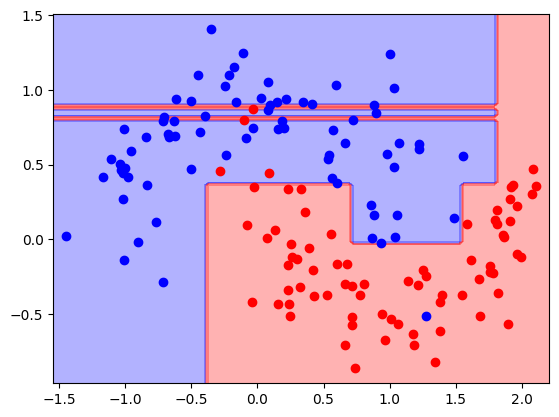

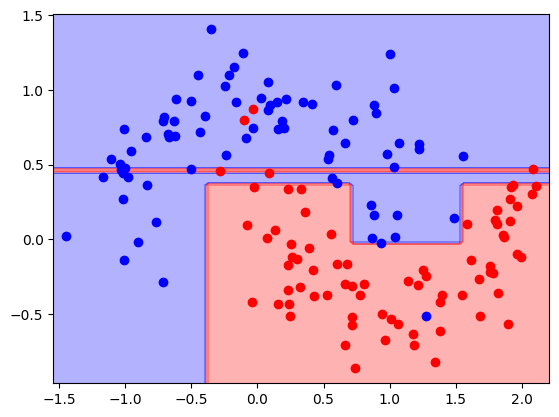

In [200]:
plot_decision_tree(tree_clf1, X_moons, y_moons, plot_training = True, configure_axes = True)
plot_decision_tree(tree_clf2, X_moons, y_moons, plot_training = True, configure_axes = True)

As we can see, tree without regularization overfitted the data.

## Regression

Decision trees can also perform regression tasks.

Let's create some quadratic dataset

In [201]:
X = np.random.rand(300, 1) - 0.5
y = X**2 + np.random.rand(300, 1) * 0.1

Now, we can train tree regressor. We won't toggle any hyperparameters, let's see how tree tends to overfit training set

In [202]:
tree_reg1 = DecisionTreeRegressor()
tree_reg1.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Function to plot training set and predictions

In [203]:
def plot_decision_tree_regression(X, y, clf, title, range_ = (-0.5, 0.5)) -> None:
    X_pred = np.linspace(range_[0], range_[1], 300).reshape(-1, 1)
    y_pred = clf.predict(X_pred)

    plt.scatter(X, y, c="blue", s=20)
    plt.plot(X_pred, y_pred, c="red",)
    plt.title(title)
    plt.grid()
    plt.show()

Plot overfitting tree

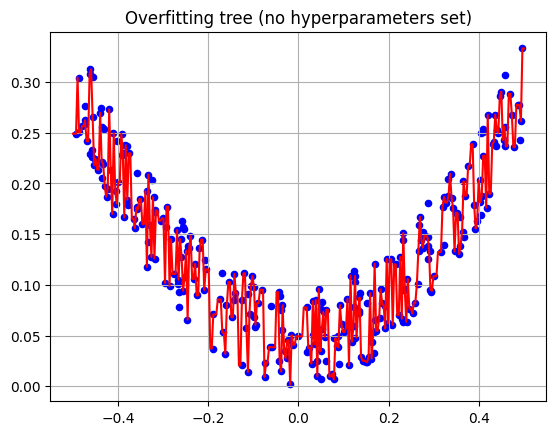

In [204]:
plot_decision_tree_regression(X, y, tree_reg1, "Overfitting tree (no hyperparameters set)",)

Plot regularized tree

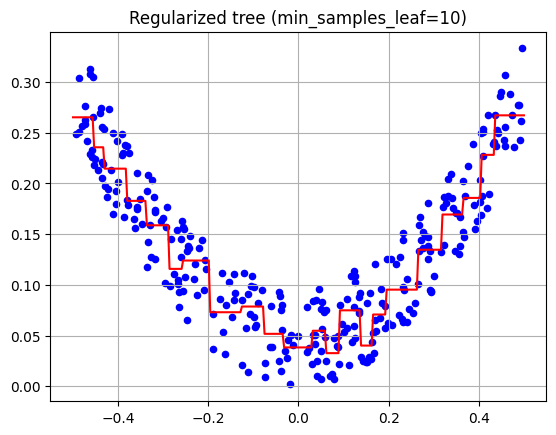

In [205]:
tree_reg2 = DecisionTreeRegressor(min_samples_leaf=10, random_state=42)
tree_reg2.fit(X, y)
plot_decision_tree_regression(X, y, tree_reg2, "Regularized tree (min_samples_leaf=10)",)

Plot tree with maximum depth set to 3

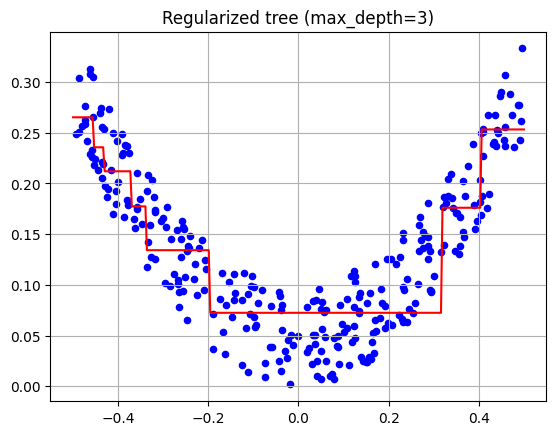

In [206]:
tree_reg_depth_3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg_depth_3.fit(X, y)
plot_decision_tree_regression(X, y, tree_reg_depth_3, "Regularized tree (max_depth=3)",)

As you can see, working with tree requires regularizing the model.

## Sensitivity to Axis Orientation

Trees are also very sensitive to the data's axis orientations. Let's create some linearly separable dataset, and rotate it by 45 degrees

In [207]:
X_1 = np.random.randint(-2, 0, (100, 1)) + np.random.rand(100, 1)
X_2 = np.random.randint(0, 2, (100, 1)) + np.random.rand(100, 1)
X = np.r_[X_1, X_2]
X = np.c_[np.random.rand(*X.shape), X]
y = np.r_[np.ones(100), np.zeros(100)]

Function to visualize decision boundaries

In [208]:
def plot_binary_classification_tree(X, y, clf, title) -> None:
    plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c="blue")
    plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], c="red")

    X1, X2 = np.linspace(np.min(X[:, 0]), np.max(X[:, 0])), np.linspace(np.min(X[:, 1]), np.max(X[:, 1]))
    X1s, X2s = np.meshgrid(X1, X2)
    X_new = np.c_[X1s.ravel(), X2s.ravel()]
    grid_predictions = clf.predict(X_new).reshape(X1s.shape)
    print(grid_predictions.shape)

    plt.contour(X1s, X2s, grid_predictions, alpha=0.5)
    plt.title(title)
    plt.title(title)
    plt.show()

Training decision tree on original dataset

(50, 50)


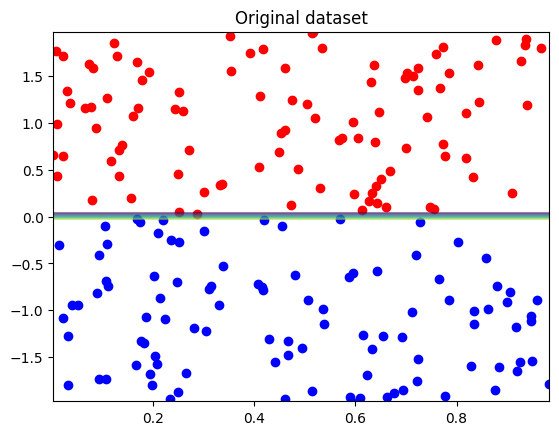

In [209]:
tree_reg = DecisionTreeRegressor()
tree_reg.fit(X, y)
plot_binary_classification_tree(X, y, tree_reg, "Original dataset")

As we can see, our classifier is simple - just one decision node.

Now, let's rotate this dataset using rotation matrix.

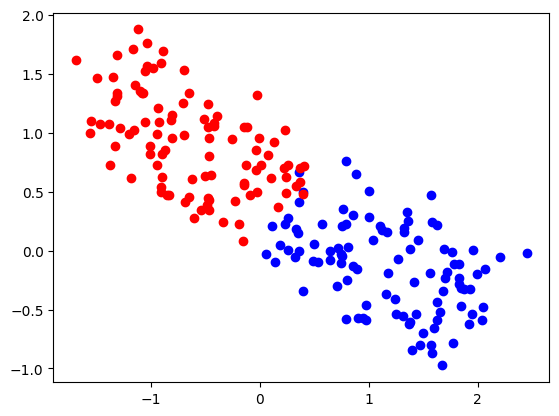

In [210]:
rotation_matrix_45 = np.array([[np.cos(45), -np.sin(45)], [np.sin(45), np.cos(45)]])

# Transposing since in programming vectors are rows.
rotated_X = rotation_matrix_45 @ X.T
rotated_X = rotated_X.T
rotated_X += np.random.randn(*rotated_X.shape) * 0.15

plt.scatter(rotated_X[:, 0][y == 1], rotated_X[:, 1][y == 1], c="blue")
plt.scatter(rotated_X[:, 0][y == 0], rotated_X[:, 1][y == 0], c="red")
plt.show()

(50, 50)


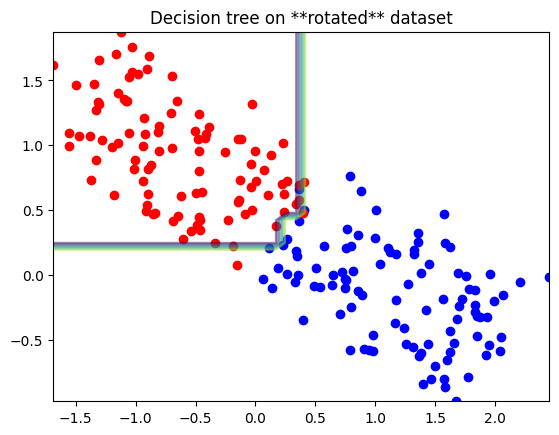

In [211]:
tree_clf = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf.fit(rotated_X, y)
plot_binary_classification_tree(rotated_X, y, tree_clf, title="Decision tree on **rotated** dataset")

As we can see - rotating leads to new decision tree. To solve this issue, you may want to use PCA, we will talk about that in future notes.

# Exercises

1. What is the approximate depth of a decision tree trained without any restrictions (no regularization) on a dataset containing one million instances?

> If the tree is well-balanced, the approximate depth would be $log_2(1\space000\space000)$

2. Is a node's Gini impurity generally lower or higher than that of its parent? Is this relationship always true, or only generally true?

> Usually, Gini impurity of parent's node is higher that the child one's, but it isn't a rule.

3. If a decision tree is overfitting the training set, would it be a good idea to decrease the `max_depth` hyperparameter?

> Yep, that is one of the many ways to regularize decision tree. Also, decision tree models have many other regularization hyperparameters, like: `min_samples_leaf`, `max_features`, `min_lead_nodes`

4. If a decision tree is underfitting the training set, is it worth trying to scale the input features?

> No, it won't help at all. Because decision trees work by feature comparison.

5. If it takes one hour to train a decision tree on a set of one million instances, roughly how much time will it take to train another tree on ten million instances? (Hint: Consider the complexity of the CART algorithm).

> It roughly takes 10 times longer, because computational complexity of CART algorithm is $O(n \cdot m \space log_2(m))$ where $n$ is number of features

6. If training takes one hour on a specific dataset, how much time will it take if you double the number of features?

> It will roughly double the computational time complexity, because it will take another $m log_2(m)$ to compute

7. Fine-Tuning a Decision Tree

    Follow these steps to build and optimize a model for the moons dataset:

    Data Generation: Use make_moons(n_samples=10000, noise=0.4) to create the dataset.

    Splitting: Use train_test_split() to divide the data into training and testing sets.

    Hyperparameter Search: Use GridSearchCV to find the best settings for a DecisionTreeClassifier. Focus on testing various values for max_leaf_nodes.

    Evaluation: Train the model on the full training set using the discovered hyperparameters and measure its accuracy on the test set. You should aim for approximately 85% to 87%.

Generate moons and split them

In [212]:
X, y = make_moons(n_samples=10000, noise=0.4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [213]:
params_grid = {
    "max_depth": [2, 3, 5],
    "max_leaf_nodes": [2, 3, 4, 5, 7, 10, 15],
    "min_samples_leaf": [1, 2, 4, 5, 7, 10]
}

grid_search_moons = GridSearchCV(DecisionTreeClassifier(), param_grid=params_grid, scoring="accuracy", cv=5, n_jobs=-1)
grid_search_moons.fit(X_train, y_train)
best_moons_tree_params = grid_search_moons.best_params_

In [214]:
print(f"Grid search best params: {grid_search_moons.best_params_}")
print(f"Grid search best score: {grid_search_moons.best_score_}")

Grid search best params: {'max_depth': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 1}
Grid search best score: 0.8548888888888889


In [215]:
best_moons_tree_clf = DecisionTreeClassifier(**grid_search_moons.best_params_)
best_moons_tree_clf.fit(X_train, y_train)
best_moons_tree_pred = best_moons_tree_clf.predict(X_test)

In [216]:
print(f"Best moon tree accuracy: {accuracy_score(y_test, best_moons_tree_pred)}")

Best moon tree accuracy: 0.859


8. Growing Your Own Random Forest

    Create a manual ensemble by following these steps:

    Subsampling: Create 1,000 subsets of the training set, each containing 100 instances selected at random (using the ShuffleSplit class is recommended).

    Individual Training: Train one decision tree on each subset using the best hyperparameter values found in the previous project. Evaluate these trees on the test set; since they are trained on smaller data, they will likely achieve only about 80% accuracy.

    Majority Voting: For every instance in the test set, generate predictions from all 1,000 trees. Keep only the most frequent prediction for each instance (you can use SciPy's mode() function).

    Final Assessment: Evaluate these majority-vote predictions on the test set. Your accuracy should be roughly 0.5% to 1.5% higher than your original single tree. Congratulations, you have built a Random Forest classifier!

In [217]:
X_splits, y_splits = [], []
ss = ShuffleSplit(n_splits=1000, test_size=0.0124, random_state=42)

for idx in ss.split(X_train):
    X_splits.append(X_train[idx[1]])
    y_splits.append(y_train[idx[1]])

X_splits, y_splits = np.array(X_splits), np.array(y_splits)

In [218]:
trees = []
scores = []

for X_subset, y_subset in zip(X_splits, y_splits):
    tree = DecisionTreeClassifier(**best_moons_tree_params)
    tree.fit(X_subset, y_subset)

    predictions = tree.predict(X_test)
    scores.append(accuracy_score(y_test, predictions))
    trees.append(tree)


In [219]:
print(f"Mean 1000 trees trained on 100 random instances score: {np.mean(scores)}")

Mean 1000 trees trained on 100 random instances score: 0.832444


In [ ]:
def predict_ensemble(X_predict: np.array, trees: np.array) -> np.array:
    predictions = []

    for x_idx in range(len(X_predict)):
        if x_idx % 10 == 0:
            print(f"Starting prediction for {x_idx}'s instance: {X_predict[x_idx]}")

        single_x_preds = [tree.predict([X_predict[x_idx]])[0] for tree in trees]
        majority_prediction_mode_result = scipy_stats.mode(single_x_preds)
        predictions.append(majority_prediction_mode_result.mode)

    return predictions

ensemble_test_predictions = predict_ensemble(X_test, trees)

Starting prediction for 0's instance: [ 0.69945888 -0.8734481 ]
Starting prediction for 10's instance: [0.18064387 1.36095828]
Starting prediction for 20's instance: [ 1.24092678 -0.34446788]
Starting prediction for 30's instance: [-1.08306383  1.16901783]
Starting prediction for 40's instance: [-0.79710368  1.06530771]
Starting prediction for 50's instance: [-1.96855083 -0.22615568]
Starting prediction for 60's instance: [ 0.35821655 -1.11827508]
Starting prediction for 70's instance: [-1.3723527   0.06909479]
Starting prediction for 80's instance: [1.59577043 1.14112599]
Starting prediction for 90's instance: [-0.75675739  0.99562166]
Starting prediction for 100's instance: [ 0.95760248 -0.0507061 ]
Starting prediction for 110's instance: [ 0.9347679  -1.03751133]
Starting prediction for 120's instance: [0.85908243 0.23570299]
Starting prediction for 130's instance: [-0.00152383  0.88399298]
Starting prediction for 140's instance: [-0.82582817  1.66161443]
Starting prediction for 150

In [226]:
print(f"Mean 1000 trees trained on 100 random instances score: {accuracy_score(y_test, ensemble_test_predictions)}")

Mean 1000 trees trained on 100 random instances score: 0.868
